In [18]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.metrics import roc_curve, roc_auc_score
from src.data import load_raw_tables, prepare_delivery_events, build_master_df, add_engineering_features
from src.preprocessing_data import split_data,  prepare_training_data

In [2]:
base_path = r"C:\Users\jinfe\.cache\kagglehub\datasets\yogape\logistics-operations-database\versions\1"
tables = load_raw_tables(base_path)
delivery_events = prepare_delivery_events(tables["delivery_events"])
df = build_master_df(
    delivery_events,
    tables["trips"],
    tables["loads"],
    tables["drivers"],
    tables["trucks"],
    tables["routes"],
    tables["customers"]
)
df = add_engineering_features(df)

In [3]:
# Final Column Selection (The Optimized List)
final_columns = [
    'on_time_flag', 
    'facility_congestion_score', 
    'facility_detention_avg',
    'hour_of_day', 
    'day_of_week', 
    'event_type',
    'booking_type',
    'weight_lbs', 
    'pieces',
    'revenue',
    'load_type',
    'years_experience', 
    'truck_age_at_event',
    'average_mpg', 
    'idle_time_hours',
    'distance_deviation',
    'is_home_terminal', 
    'detention_risk_index', 
    'efficiency_ratio', 
    'revenue_density',
    'is_winter'
]

In [4]:
# Separate Features and Target
categorical_cols = ['day_of_week', 'event_type', 'booking_type', 'load_type']
numeric_cols = [
    'facility_congestion_score', 'facility_detention_avg', 'hour_of_day', 
    'weight_lbs', 'pieces', 'revenue', 'years_experience', 
    'truck_age_at_event', 'average_mpg', 'idle_time_hours', 'distance_deviation',
    'is_home_terminal', 'detention_risk_index', 'efficiency_ratio', 'revenue_density','is_winter'
]
target = 'on_time_flag'

In [5]:
# Create df for model training
df_model = df[categorical_cols + numeric_cols + [target]].copy()

In [6]:
# ONE-HOT ENCODING to convertstext categories into 0/1 columns
df_encoded = pd.get_dummies(df_model, columns=categorical_cols, drop_first=True)

In [7]:
# 5. Split data
X_train, X_test, y_train, y_test = split_data(
    df_encoded=df_encoded,
    target=target,
    test_size=0.2,
    random_state=42)
# 6. Impute missing values
imputer = SimpleImputer(strategy="median")

X_train_imputed = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test_imputed = pd.DataFrame(
    imputer.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)    

In [8]:
# 7. Train Random Forest
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_imputed, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [9]:
# 8. Predict
y_pred = rf_model.predict(X_test_imputed)

In [10]:
# 9. Evaluate
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Random Forest Results")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Random Forest Results
Accuracy : 0.6360
Precision: 0.6680
Recall   : 0.6880
F1 Score : 0.6779


In [11]:
# 10. Detailed report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

       False       0.59      0.57      0.58     15145
        True       0.67      0.69      0.68     19019

    accuracy                           0.64     34164
   macro avg       0.63      0.63      0.63     34164
weighted avg       0.63      0.64      0.64     34164




Confusion Matrix:


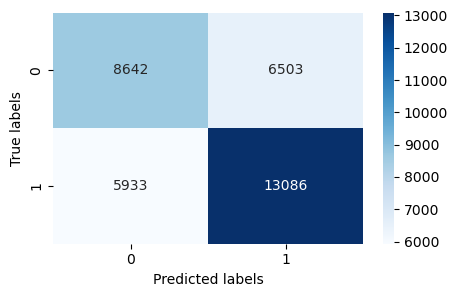

In [16]:
# 11. Confusion matrix
print("\nConfusion Matrix:")
cm=confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 3))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",          # <-- THIS is the key line
    cmap="Blues"
)
plt.xlabel("Predicted labels")
plt.ylabel("True labels")
plt.show()

In [17]:
# 12. Results table
results_df = pd.DataFrame([
    {
        "Model": "Random Forest",
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    }
])

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest,0.635991,0.668028,0.688049,0.677891


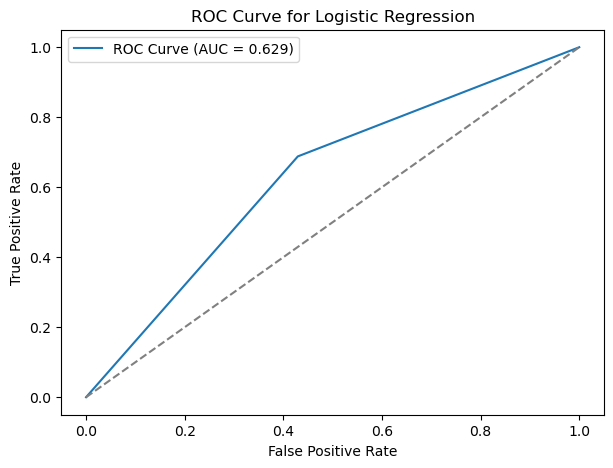

In [19]:
# Compute ROC curve values
fpr, tpr, thresholds = roc_curve(y_test, y_pred)
# Compute AUC
auc = roc_auc_score(y_test, y_pred)
# Plot
plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")  # diagonal line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Logistic Regression")
plt.legend()
plt.show()